# 딥러닝 3일차

In [1]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
# 실행할 때마다 랜덤 값이 동일하게 나오고 싶으면, seed 지정할 것
# keras.utils.set_random_seed(42)
# tf.random.set_seed(42)
# tf.config.experimental.enable_op_determinism()

In [3]:
# 데이터 불러오기 (학습 데이터만)
(train_input, train_target), _ = keras.datasets.fashion_mnist.load_data()
train_scale = train_input / 255.0

In [4]:
train_scaled, val_scaled, train_target, val_test = train_test_split(train_scale, train_target, test_size=0.2)

In [5]:
train_scaled.shape, val_scaled.shape

((48000, 28, 28), (12000, 28, 28))

In [6]:
# 모델 생성 함수
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28,28)))    #입력
    model.add(keras.layers.Flatten())   # 평탄화 784
    model.add(keras.layers.Dense(100, activation='relu')) # 은닉층
    if a_layer:
        model.add(a_layer)  # 매개변수가 있는 경우에만 선택적으로 삽입하는 layer
    model.add(keras.layers.Dense(10, activation='softmax')) # 출력층
    return model


In [7]:
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5374 - sparse_categorical_accuracy: 0.8101
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3922 - sparse_categorical_accuracy: 0.8593
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3559 - sparse_categorical_accuracy: 0.8725
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3300 - sparse_categorical_accuracy: 0.8817
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3184 - sparse_categorical_accuracy: 0.8865


In [8]:
import keras, tensorflow as tf
from sklearn.model_selection import train_test_split

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

(train_input, train_target), _ = \
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(train_scaled, train_target,
                     test_size=0.2, random_state=42)

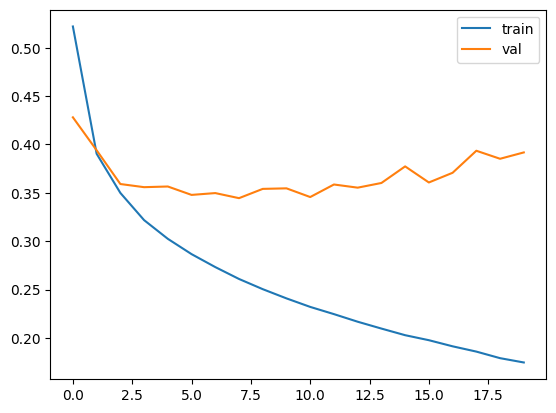

In [9]:
from matplotlib import pyplot as plt


model = model_fn()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

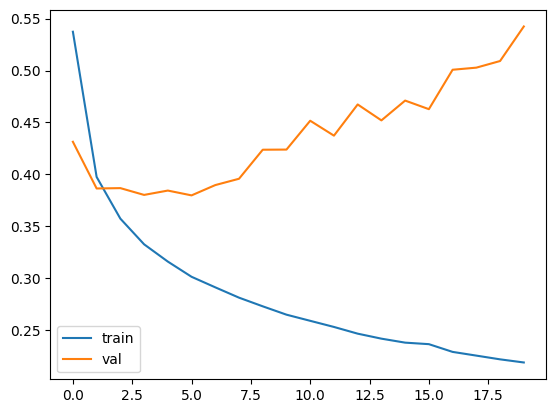

In [10]:
# rmsprop 기본값
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

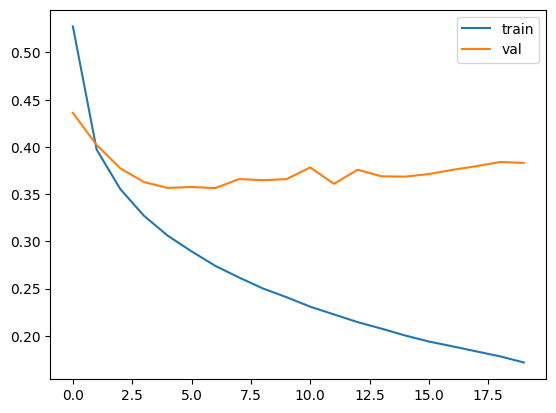

In [11]:
# Adam
model = model_fn()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

In [12]:
history.history['loss']

[0.5275392532348633,
 0.39718595147132874,
 0.3552376627922058,
 0.3269360661506653,
 0.30591413378715515,
 0.28937435150146484,
 0.27402374148368835,
 0.26169461011886597,
 0.25014275312423706,
 0.2408771514892578,
 0.23079118132591248,
 0.22259895503520966,
 0.21441933512687683,
 0.20757052302360535,
 0.20027047395706177,
 0.19389113783836365,
 0.1887756735086441,
 0.183439701795578,
 0.17818468809127808,
 0.17169752717018127]

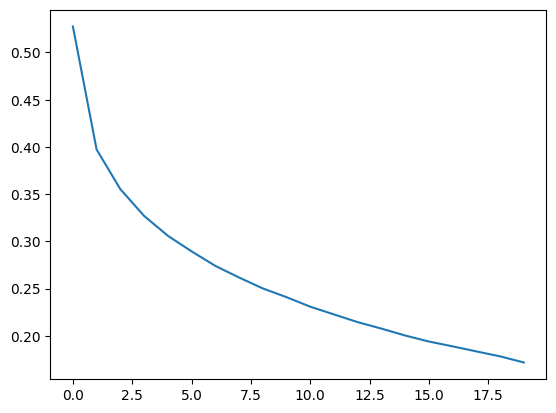

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.5291 - sparse_categorical_accuracy: 0.8113 - val_loss: 0.4305 - val_sparse_categorical_accuracy: 0.8473
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3915 - sparse_categorical_accuracy: 0.8581 - val_loss: 0.3966 - val_sparse_categorical_accuracy: 0.8569
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3529 - sparse_categorical_accuracy: 0.8729 - val_loss: 0.3854 - val_sparse_categorical_accuracy: 0.8614
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3288 - sparse_categorical_accuracy: 0.8817 - val_loss: 0.4045 - val_sparse_categorical_accuracy: 0.8550
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3131 - sparse_categorical_accuracy: 0.8878 - val_loss: 0.3863 - val_sparse_categorical_accuracy: 0.8662
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3003 - sparse_categorical_accuracy: 0.8932 - val_loss: 0.4086 - val_sparse_categorical_accuracy:

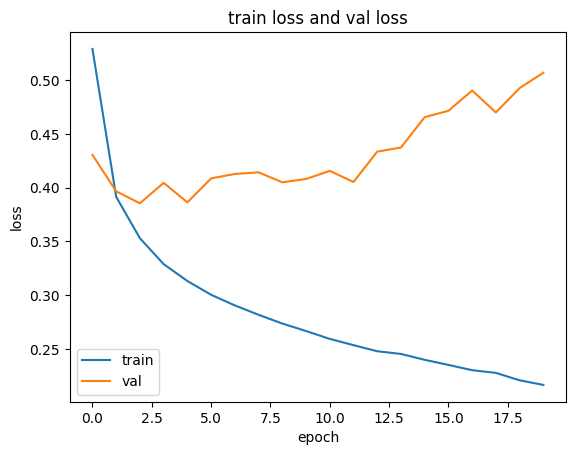

In [14]:
# validation 검증 데이터와 손실(loss) 비교
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss')
plt.show()

# DropOut

In [15]:
model = model_fn(keras.layers.Dropout(0.3)) # 드롭 아웃 층을 추가
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

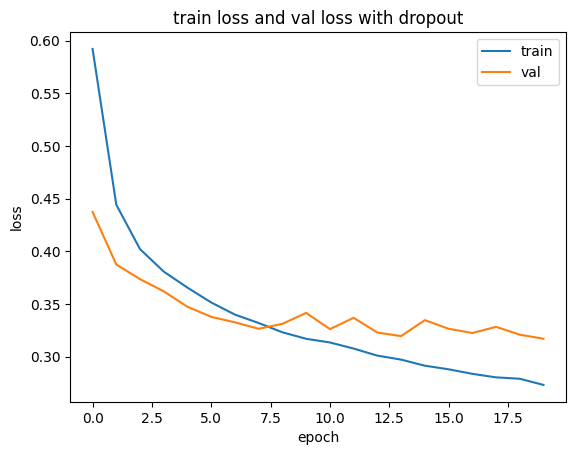

In [16]:
model = model_fn(keras.layers.Dropout(0.3)) # 드롭 아웃 층을 추가
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss with dropout')
plt.show()

In [17]:
# 드롭아웃 외에도 정규화 방법들이 존재
# L2 정규화 : 수학적 해석 명확, 소규모 데이터셋에서 안정적으로 작동, 랜덤 요소 없음.
model.add(keras.layers.Dense(100, activation='relu', kernel_regularizer='l2'))

# DropOut : 컴퓨터비전(cv)에서 표준.

## 모델 저장

In [18]:
model.save('model.keras')   # 모델의 구조와 가중치를 모두 저장

In [20]:
model.save('model-whole.keras')       # 구조+가중치
model.save_weights('model.weights.h5') # 가중치만

In [21]:
model2 = model_fn(keras.layers.Dropout(0.3))
model2.load_weights('model.weights.h5')

In [23]:
model3 = keras.models.load_model('model.keras')

c:\Users\student\p1-data\c3-deep-leanring\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [24]:
model3.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 1.6667e-04 - loss: 13.4428


[13.442822456359863, 0.00016666666488163173]

## CallBack
- 학습(fit) 실행 중, 특정 이벤트에 자동으로 동작하는 하뭇.

In [26]:
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only='True')

In [27]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=1, validation_data=(val_scaled, val_target), callbacks=[checkpoint])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7928 - loss: 0.5886 - val_accuracy: 0.8440 - val_loss: 0.4355
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8413 - loss: 0.4411 - val_accuracy: 0.8547 - val_loss: 0.3883
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8561 - loss: 0.4026 - val_accuracy: 0.8670 - val_loss: 0.3635
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8603 - loss: 0.3829 - val_accuracy: 0.8698 - val_loss: 0.3520
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8671 - loss: 0.3632 - val_accuracy: 0.8723 - val_loss: 0.3516
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8711 - loss: 0.3518 - val_accuracy: 0.8763 - val_loss: 0.3372
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8740 - loss: 0.3405 - val_accuracy: 0.8773 - val_loss: 0.3345
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8773 - loss: 0.3317 - 

In [28]:
# 최적의 모델 불러오기
model_best = keras.models.load_model('best-model.keras')

In [29]:
model_best.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - accuracy: 0.8867 - loss: 0.3135


[0.31347590684890747, 0.8866666555404663]

# 조기종료

In [30]:
keras.callbacks.EarlyStopping(monitor="val_loss", patience=2,
                              restore_best_weights=True)

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=1, validation_data=(val_scaled, val_target), callbacks=[checkpoint, early_stopping.stoppend])